In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR='/content/drive/MyDrive/Thesis'
zip_file_path=BASE_DIR+'/splited-main.zip'
extract_to_directory = BASE_DIR+'/extracted_main_dataset'

In [ ]:
import zipfile
import os

def unzip_file(zip_path, extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# Specify the path to the zip file and the directory to extract to

# Create the directory if it doesn't exist
os.makedirs(extract_to_directory, exist_ok=True)

# Unzip the file
unzip_file(zip_file_path, extract_to_directory)

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import cv2
import albumentations as A
from skimage.io import imread
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

In [ ]:
folder_path = extract_to_directory+'/train'
dirs = os.listdir(folder_path)
print(dirs)

['Banana-immature', 'Banana-mature', 'Banana-semimature', 'Guava_Immature', 'Guava_Mature', 'Guava_Semi-mature', 'Lemon-immature', 'Lemon-mature', 'Lemon-semimature', 'Mango-immature', 'Mango-mature', 'Mango-semimature', 'Papaya-immature', 'Papaya-mature', 'Papaya-semimature', 'Tomatoo-immature', 'Tomatoo-mature', 'Tomatoo-semimature']


In [ ]:
for i in range(len(dirs)):
    types = set()
    for n in os.listdir(os.path.join(folder_path, dirs[i])):
        types.add(n.split('.')[-1])

    print(dirs[i] + ':', types)


Banana-immature: {'jpg'}
Banana-mature: {'jpg'}
Banana-semimature: {'jpg'}
Guava_Immature: {'jpg'}
Guava_Mature: {'jpg'}
Guava_Semi-mature: {'jpg'}
Lemon-immature: {'jpg'}
Lemon-mature: {'jpg'}
Lemon-semimature: {'jpg'}
Mango-immature: {'jpg'}
Mango-mature: {'jpg'}
Mango-semimature: {'jpg'}
Papaya-immature: {'jpg'}
Papaya-mature: {'jpg'}
Papaya-semimature: {'jpg'}
Tomatoo-immature: {'jpg'}
Tomatoo-mature: {'jpg'}
Tomatoo-semimature: {'jpg'}


In [ ]:
for i in range(len(dirs)):
    class_folder = os.path.join(folder_path, dirs[i])
    files_path = os.listdir(class_folder)
    size = set()

    #fp = files_path
    for fp in files_path:
        img = imread(os.path.join(class_folder, fp))
        size.add(img.shape)

    print('(Height, Width, Channels)')
    print(70*'-')
    print(dirs[i] + ':', size)

(Height, Width, Channels)
----------------------------------------------------------------------
Banana-immature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Banana-mature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Banana-semimature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Guava_Immature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Guava_Mature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Guava_Semi-mature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Lemon-immature: {(320, 320, 3)}
(Height, Width, Channels)
-------------------------------------------------------------------

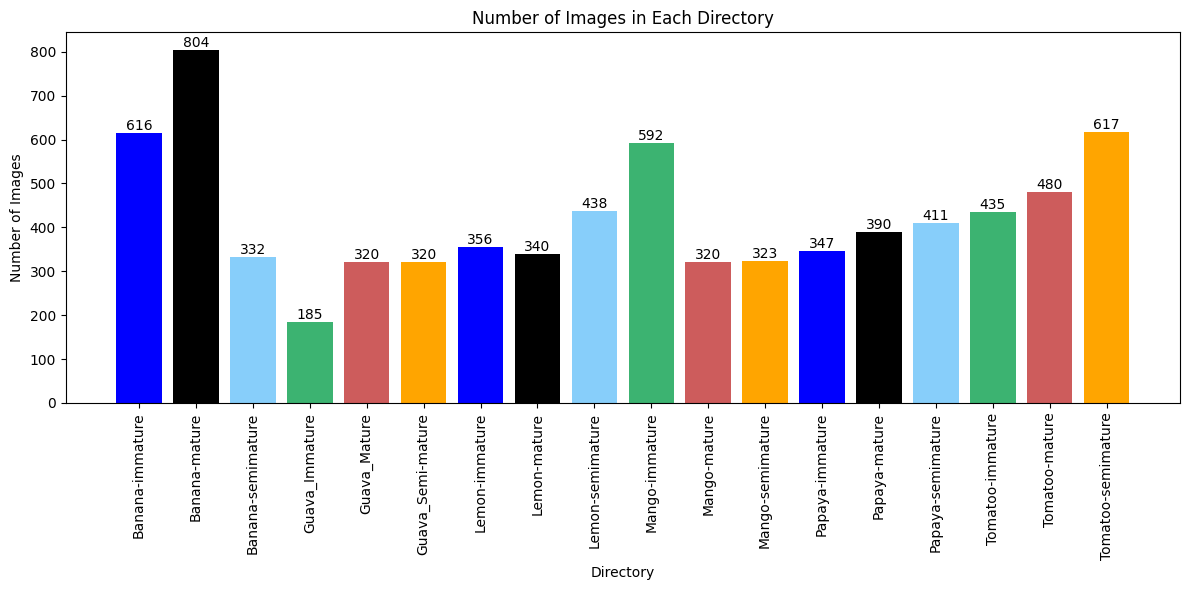

In [ ]:
image_counts = []
for directory in dirs:
    sub_dir = os.path.join(folder_path, directory)
    if os.path.isdir(sub_dir):
        file_count = len(os.listdir(sub_dir))
        image_counts.append(file_count)


plt.figure(figsize=(12,6))
for i in range(len(dirs)):
    plt.text(i, image_counts[i], str(image_counts[i]), ha='center', va='bottom')


colors = ['blue','black','lightskyblue', 'mediumseagreen', 'indianred', 'orange']


plt.bar(dirs, image_counts, color=colors)
plt.xlabel('Directory')
plt.xticks(rotation=90)
plt.ylabel('Number of Images')
plt.title('Number of Images in Each Directory')
plt.tight_layout()
plt.show()

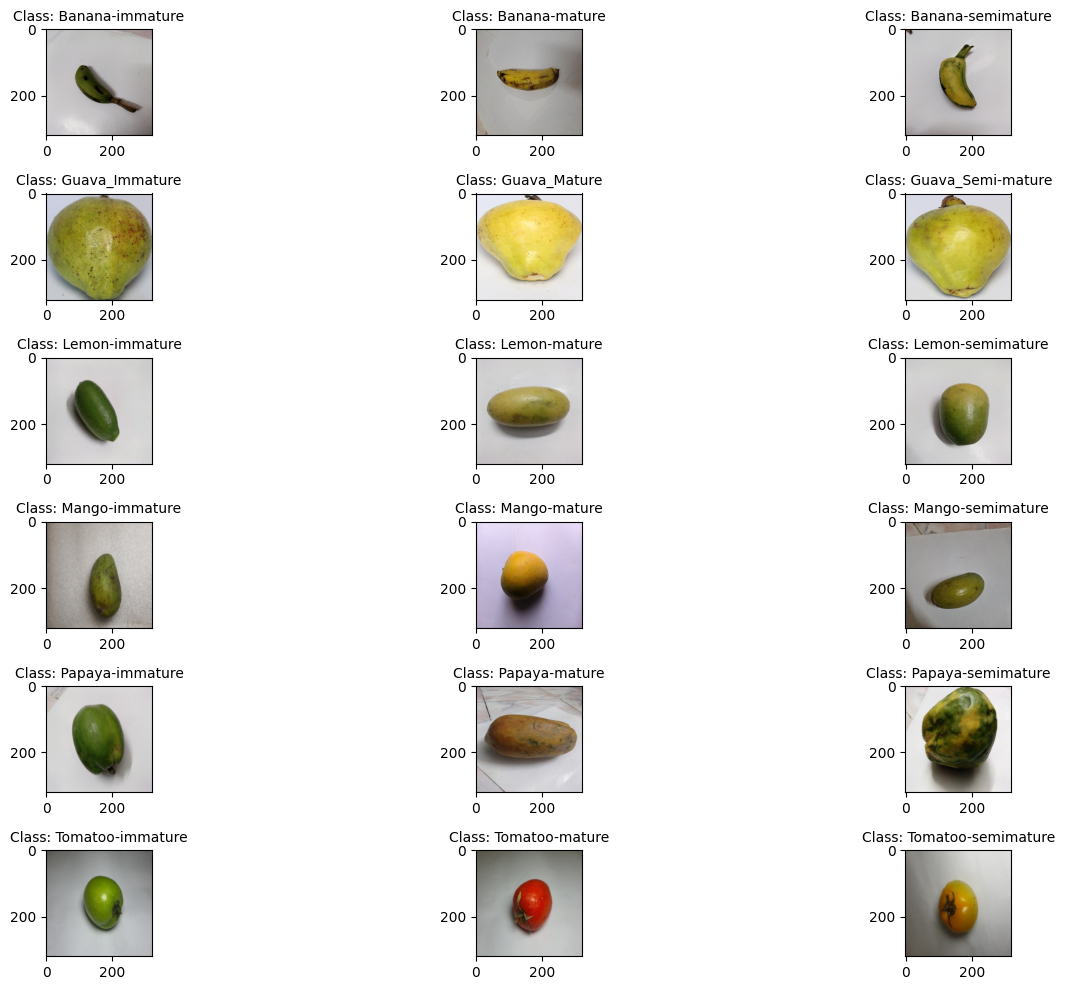

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set the path to the parent directory containing class folders
parent_directory = folder_path

# Get a list of class folders (assuming folder names correspond to class names)
class_folders = os.listdir(parent_directory)

# Define the number of images to print from each class (in this case, 1)
num_images_to_print = 1

# Calculate the number of rows and columns for the subplots
num_rows = 6
num_cols = 3

# Calculate the total number of subplots
total_subplots = num_rows * num_cols

# Create a single figure with subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Iterate through each class folder
for idx, class_folder in enumerate(class_folders):
    if idx >= total_subplots:
        break  # Exit the loop if there are more classes than available subplots

    class_path = os.path.join(parent_directory, class_folder)

    # Get a list of image files in the class folder
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]

    # Check if there is at least one image in the class folder
    if len(image_files) > 0:
        # Randomly select one image to print
        random_image = random.choice(image_files)

        # Calculate the row and column index for the subplot
        row = idx // num_cols
        col = idx % num_cols

        # Load and plot the selected image
        image_path = os.path.join(class_path, random_image)
        image = mpimg.imread(image_path)

        # Plot the image in the appropriate subplot
        axs[row, col].imshow(image)
        axs[row, col].set_title(f'Class: {class_folder}', fontsize=10)  # Adjust text size
        axs[row, col].axis('on')

# Remove any remaining empty subplots
for idx in range(len(class_folders), total_subplots):
    row = idx // num_cols
    col = idx % num_cols
    fig.delaxes(axs[row, col])

# Adjust spacing between subplots
plt.tight_layout()

# Show the single figure containing all subplots
plt.show()

In [ ]:
base_dest_dir = BASE_DIR+'/split'  # Base directory in Colab environment

In [ ]:
train_ratio=float(0.7)
test_ratio=float(0.15)

In [ ]:
split_seed=42

In [ ]:
import os
import shutil
import random

# Set paths for source and destination directories
source_dir = folder_path

# Create base destination directory
os.makedirs(base_dest_dir, exist_ok=True)

# Get a list of all subdirectories in the source directory
subdirectories = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

# Loop through each subdirectory and split images
for subdir in subdirectories:
    subdir_path = os.path.join(source_dir, subdir)

    # Create train, test, and validation subdirectories
    train_dir = os.path.join(base_dest_dir, 'train', subdir)
    test_dir = os.path.join(base_dest_dir, 'test', subdir)
    validation_dir = os.path.join(base_dest_dir, 'validation', subdir)

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    os.makedirs(validation_dir, exist_ok=True)

    # List all image files in the subdirectory
    image_files = [f for f in os.listdir(subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Shuffle the image files
    random.seed(split_seed)
    random.shuffle(image_files)

    # Calculate the number of images for each split
    total_images = len(image_files)
    train_count = int(train_ratio * total_images)
    test_count = int(test_ratio * total_images)
    validation_count = total_images - train_count - test_count

    # Split the image files into train, test, and validation sets
    train_images = image_files[:train_count]
    test_images = image_files[train_count:train_count + test_count]
    validation_images = image_files[train_count + test_count:]

    # Function to copy images from source to destination
    def copy_images(image_list, source, dest):
        for image in image_list:
            src_path = os.path.join(source, subdir, image)
            dest_path = os.path.join(dest, image)
            shutil.copy(src_path, dest_path)

    # Copy images to respective subdirectories
    copy_images(train_images, source_dir, train_dir)
    copy_images(test_images, source_dir, test_dir)
    copy_images(validation_images, source_dir, validation_dir)
print(f"Spliting finished! with train ratio = {train_ratio} and test ratio = {test_ratio} and validation_ratio={1-(train_ratio+test_ratio):.2F}" )
print(f"Count of images:\nTrain={train_count}\nTest={test_count}\nValidation={validation_count}")

KeyboardInterrupt: ignored

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import itertools
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from PIL import Image
from sklearn.metrics import classification_report, f1_score , confusion_matrix



# Tensorflow Libraries
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout , BatchNormalization
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers,models,Model
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


print(tf.__version__)

2.14.0


In [ ]:
base_dest_dir='/content/drive/MyDrive/Thesis/extracted_main_dataset'

In [ ]:
train_path=base_dest_dir+'/train'
test_path=base_dest_dir+'/test'
val_path=base_dest_dir+'/validation'

In [ ]:
dataset = {
             "train_data" : train_path,
             "valid_data" : val_path,
             "test_data" : test_path
          }

all_data = []
for path in dataset.values():
    data = {"imgpath": [] , "labels": [] }
    category = os.listdir(path)

    for folder in category:
        folderpath = os.path.join(path , folder)
        filelist = os.listdir(folderpath)
        for file in filelist:
            fpath = os.path.join(folderpath, file)
            data["imgpath"].append(fpath)
            data["labels"].append(folder)


    all_data.append(data.copy())
    data.clear()



train_df = pd.DataFrame(all_data[0] , index=range(len(all_data[0]['imgpath'])))
valid_df = pd.DataFrame(all_data[1] , index=range(len(all_data[1]['imgpath'])))
test_df = pd.DataFrame(all_data[2] , index=range(len(all_data[2]['imgpath'])))


# #Convert labels to numbers
lb = LabelEncoder()
train_df['encoded_labels'] = lb.fit_transform(train_df['labels'])
valid_df['encoded_labels'] = lb.fit_transform(valid_df['labels'])
test_df['encoded_labels'] = lb.fit_transform(test_df['labels'])

In [ ]:
train_df.sample(n=15, random_state=1)

,imgpath,labels,encoded_labels
1949,/content/drive/MyDrive/Thesis/extracted_main_d...,Guava_Mature,4
958,/content/drive/MyDrive/Thesis/extracted_main_d...,Banana-mature,1
4417,/content/drive/MyDrive/Thesis/extracted_main_d...,Mango-mature,10
6876,/content/drive/MyDrive/Thesis/extracted_main_d...,Tomatoo-mature,16
5824,/content/drive/MyDrive/Thesis/extracted_main_d...,Papaya-semimature,14
4589,/content/drive/MyDrive/Thesis/extracted_main_d...,Mango-mature,10
5508,/content/drive/MyDrive/Thesis/extracted_main_d...,Papaya-mature,13
5481,/content/drive/MyDrive/Thesis/extracted_main_d...,Papaya-mature,13
6137,/content/drive/MyDrive/Thesis/extracted_main_d...,Tomatoo-immature,15
7425,/content/drive/MyDrive/Thesis/extracted_main_d...,Tomatoo-semimature,17


In [ ]:
print("----------Train-------------")
print(train_df[["imgpath", "labels"]].head(5))
print(train_df.shape)
print("--------Validation----------")
print(valid_df[["imgpath", "labels"]].head(5))
print(valid_df.shape)
print("----------Test--------------")
print(test_df[["imgpath", "labels"]].head(5))
print(test_df.shape)

----------Train-------------
                                             imgpath           labels
0  /content/drive/MyDrive/Thesis/extracted_main_d...  Banana-immature
1  /content/drive/MyDrive/Thesis/extracted_main_d...  Banana-immature
2  /content/drive/MyDrive/Thesis/extracted_main_d...  Banana-immature
3  /content/drive/MyDrive/Thesis/extracted_main_d...  Banana-immature
4  /content/drive/MyDrive/Thesis/extracted_main_d...  Banana-immature
(7626, 3)
--------Validation----------
                                             imgpath           labels
0  /content/drive/MyDrive/Thesis/extracted_main_d...  Banana-immature
1  /content/drive/MyDrive/Thesis/extracted_main_d...  Banana-immature
2  /content/drive/MyDrive/Thesis/extracted_main_d...  Banana-immature
3  /content/drive/MyDrive/Thesis/extracted_main_d...  Banana-immature
4  /content/drive/MyDrive/Thesis/extracted_main_d...  Banana-immature
(1171, 3)
----------Test--------------
                                             imgpath 

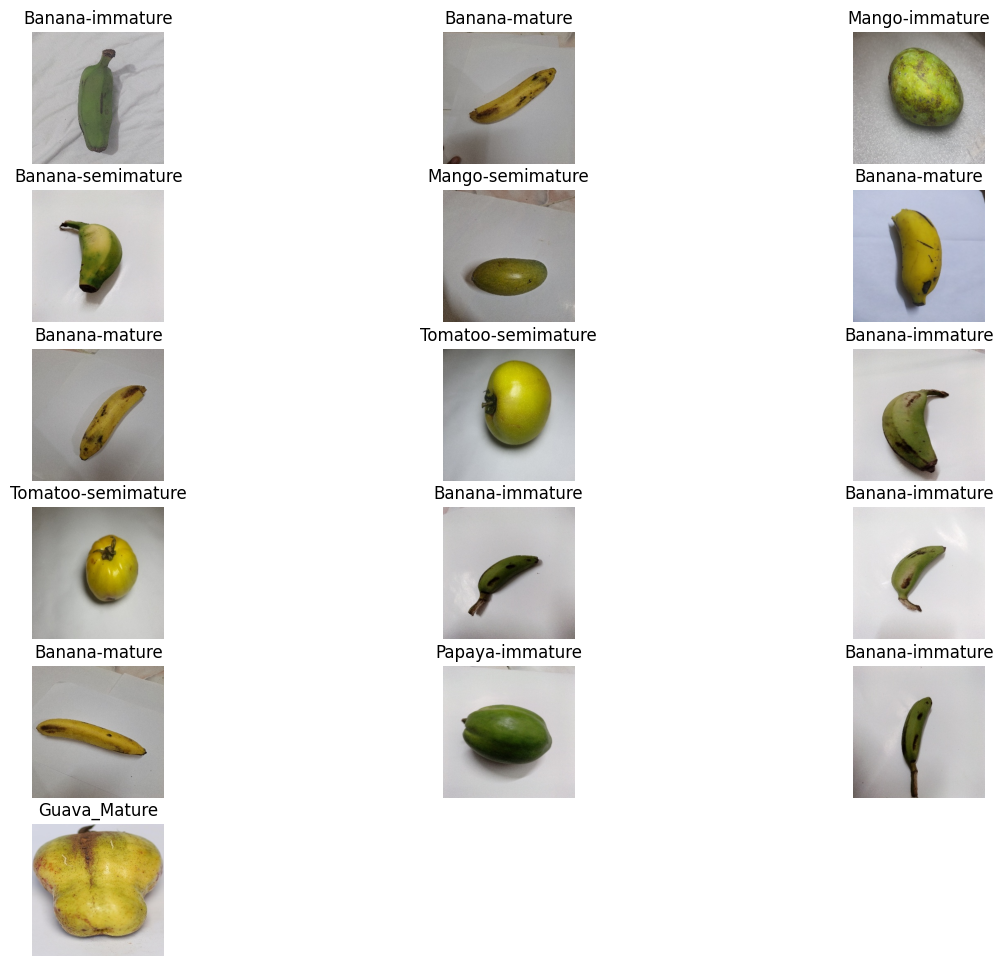

In [ ]:
plt.figure(figsize=(15,12))
for i, row in valid_df.sample(n=16).reset_index().iterrows():
    plt.subplot(6,3,i+1)
    image_path = row['imgpath']
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(row["labels"])
    plt.axis('off')
plt.show()

In [ ]:
%%time
def image_gen_and_preprocess(preprocess_func):
  BATCH_SIZE = 32
  IMAGE_SIZE = (224, 224)
  generator = ImageDataGenerator(
      preprocessing_function = preprocess_func,
      # there could be image augmentation here
  )
  # Split the data into three categories.
  train_images = generator.flow_from_dataframe(
      dataframe=train_df,
      x_col='imgpath',
      y_col='labels',
      target_size=IMAGE_SIZE,
      color_mode='rgb',
      class_mode='categorical',
      batch_size=BATCH_SIZE,
      shuffle=True,
      seed=42,
  )
  val_images = generator.flow_from_dataframe(
      dataframe=valid_df,
      x_col='imgpath',
      y_col='labels',
      target_size=IMAGE_SIZE,
      color_mode='rgb',
      class_mode='categorical',
      batch_size=BATCH_SIZE,
      shuffle=False
  )
  test_images = generator.flow_from_dataframe(
      dataframe=test_df,
      x_col='imgpath',
      y_col='labels',
      target_size=IMAGE_SIZE,
      color_mode='rgb',
      class_mode='categorical',
      batch_size=BATCH_SIZE,
      shuffle=False
  )
  return train_images,val_images,test_images

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 6.2 µs


In [ ]:
keras.backend.clear_session()

In [ ]:
from tensorflow.keras.applications import mobilenet_v2,mobilenet_v3, vgg16, vgg19,xception,resnet50,nasnet,inception_v3,inception_resnet_v2,efficientnet,efficientnet_v2,densenet,resnet,resnet_v2

In [36]:
# Define a dictionary mapping each model to its preprocess_input function
preprocess_functions = {
    'MobileNetV2': mobilenet_v2.preprocess_input,
    'VGG16': vgg16.preprocess_input,
    'VGG19': vgg19.preprocess_input,
    'Xception':xception.preprocess_input,
    'ResNet50':resnet50.preprocess_input,
    'NASNetMobile':nasnet.preprocess_input,
    'InceptionV3':inception_v3.preprocess_input,
    'DenseNet201':densenet.preprocess_input,
      'EfficientNetB7':efficientnet.preprocess_input,
      'EfficientNetB0':efficientnet.preprocess_input,
    # Add more models and their respective preprocess_input functions here
}

In [ ]:
#Create necessary directory to save loss graph.
loss_graph=f'{BASE_DIR}/loss_graph/'
if not os.path.exists(loss_graph):
  os.makedirs(loss_graph)


In [ ]:
#Create necessary directory to save confusion matrix
confusion=f'{BASE_DIR}/confusion_matrix/'
if not os.path.exists(confusion):
  os.makedirs(confusion)

Key: EfficientNetB7, Value: <function preprocess_input at 0x7f1d5dcb6dd0>
Found 7626 validated image filenames belonging to 18 classes.
Found 1171 validated image filenames belonging to 18 classes.
Found 1121 validated image filenames belonging to 18 classes.
258076736/258076736 [==============================] - 2s 0us/step
Epoch 1/100
239/239 [==============================] - 94s 268ms/step - loss: 0.7246 - accuracy: 0.7986 - val_loss: 9.3001 - val_accuracy: 0.4039 - lr: 0.0100
Epoch 2/100
239/239 [==============================] - 59s 245ms/step - loss: 0.3354 - accuracy: 0.8963 - val_loss: 0.5961 - val_accuracy: 0.8446 - lr: 0.0100
Epoch 3/100
239/239 [==============================] - 56s 236ms/step - loss: 0.2200 - accuracy: 0.9321 - val_loss: 0.9311 - val_accuracy: 0.8284 - lr: 0.0100
Epoch 4/100
239/239 [==============================] - 57s 237ms/step - loss: 0.1636 - accuracy: 0.9453 - val_loss: 0.7735 - val_accuracy: 0.8506 - lr: 0.0100
Epoch 5/100
239/239 [================

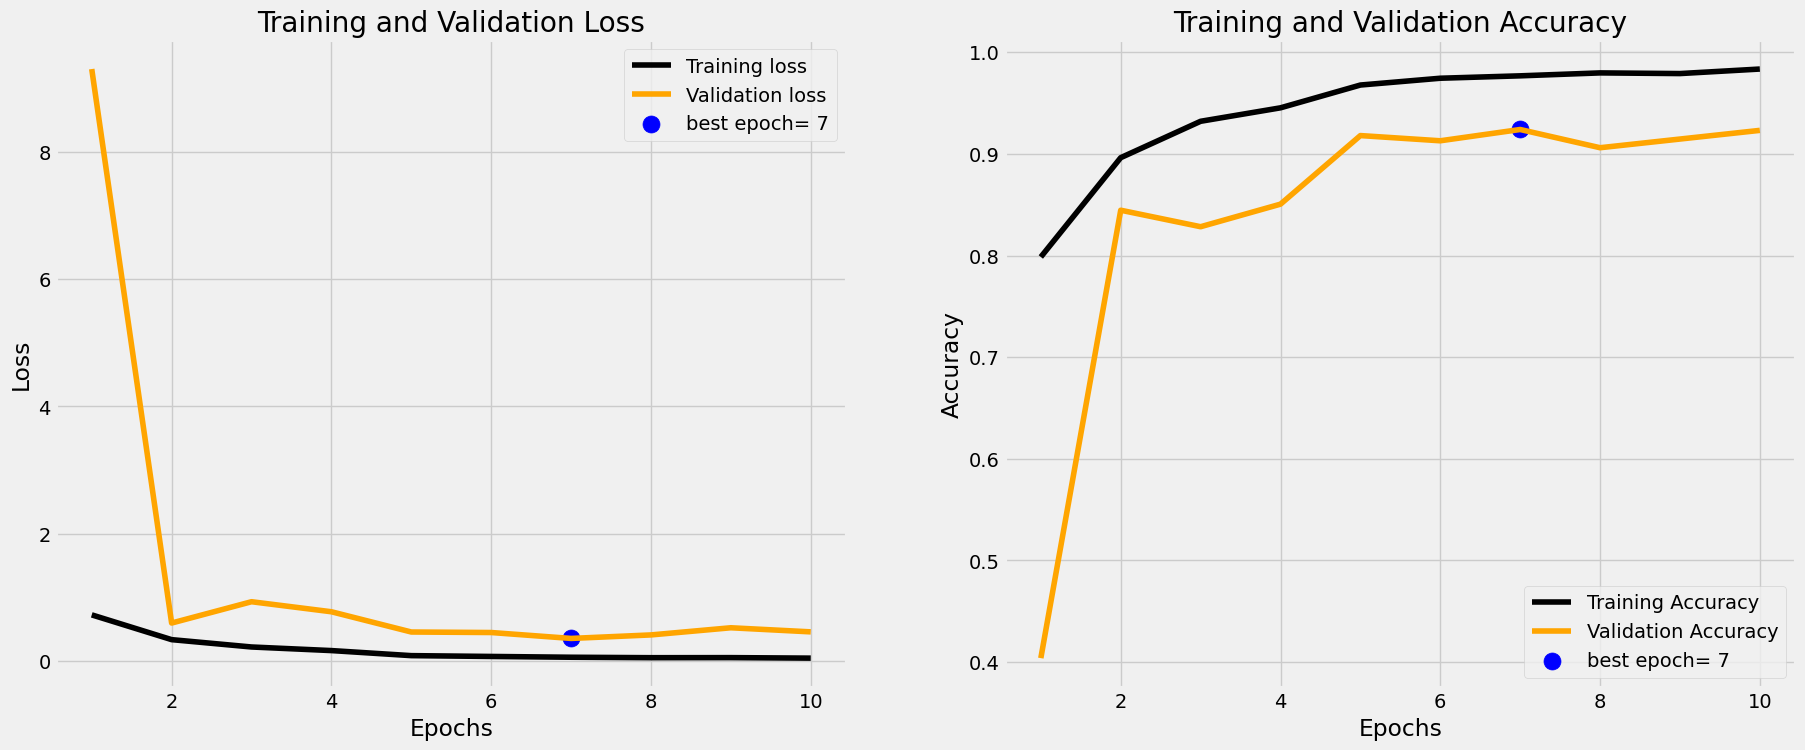

Evaluation results for EfficientNetB7 saved to /content/drive/MyDrive/Thesis/result.txt
36/36 [==============================] - 15s 186ms/step
F1 Score and Classification Report for EfficientNetB7 saved to /content/drive/MyDrive/Thesis/result.txt


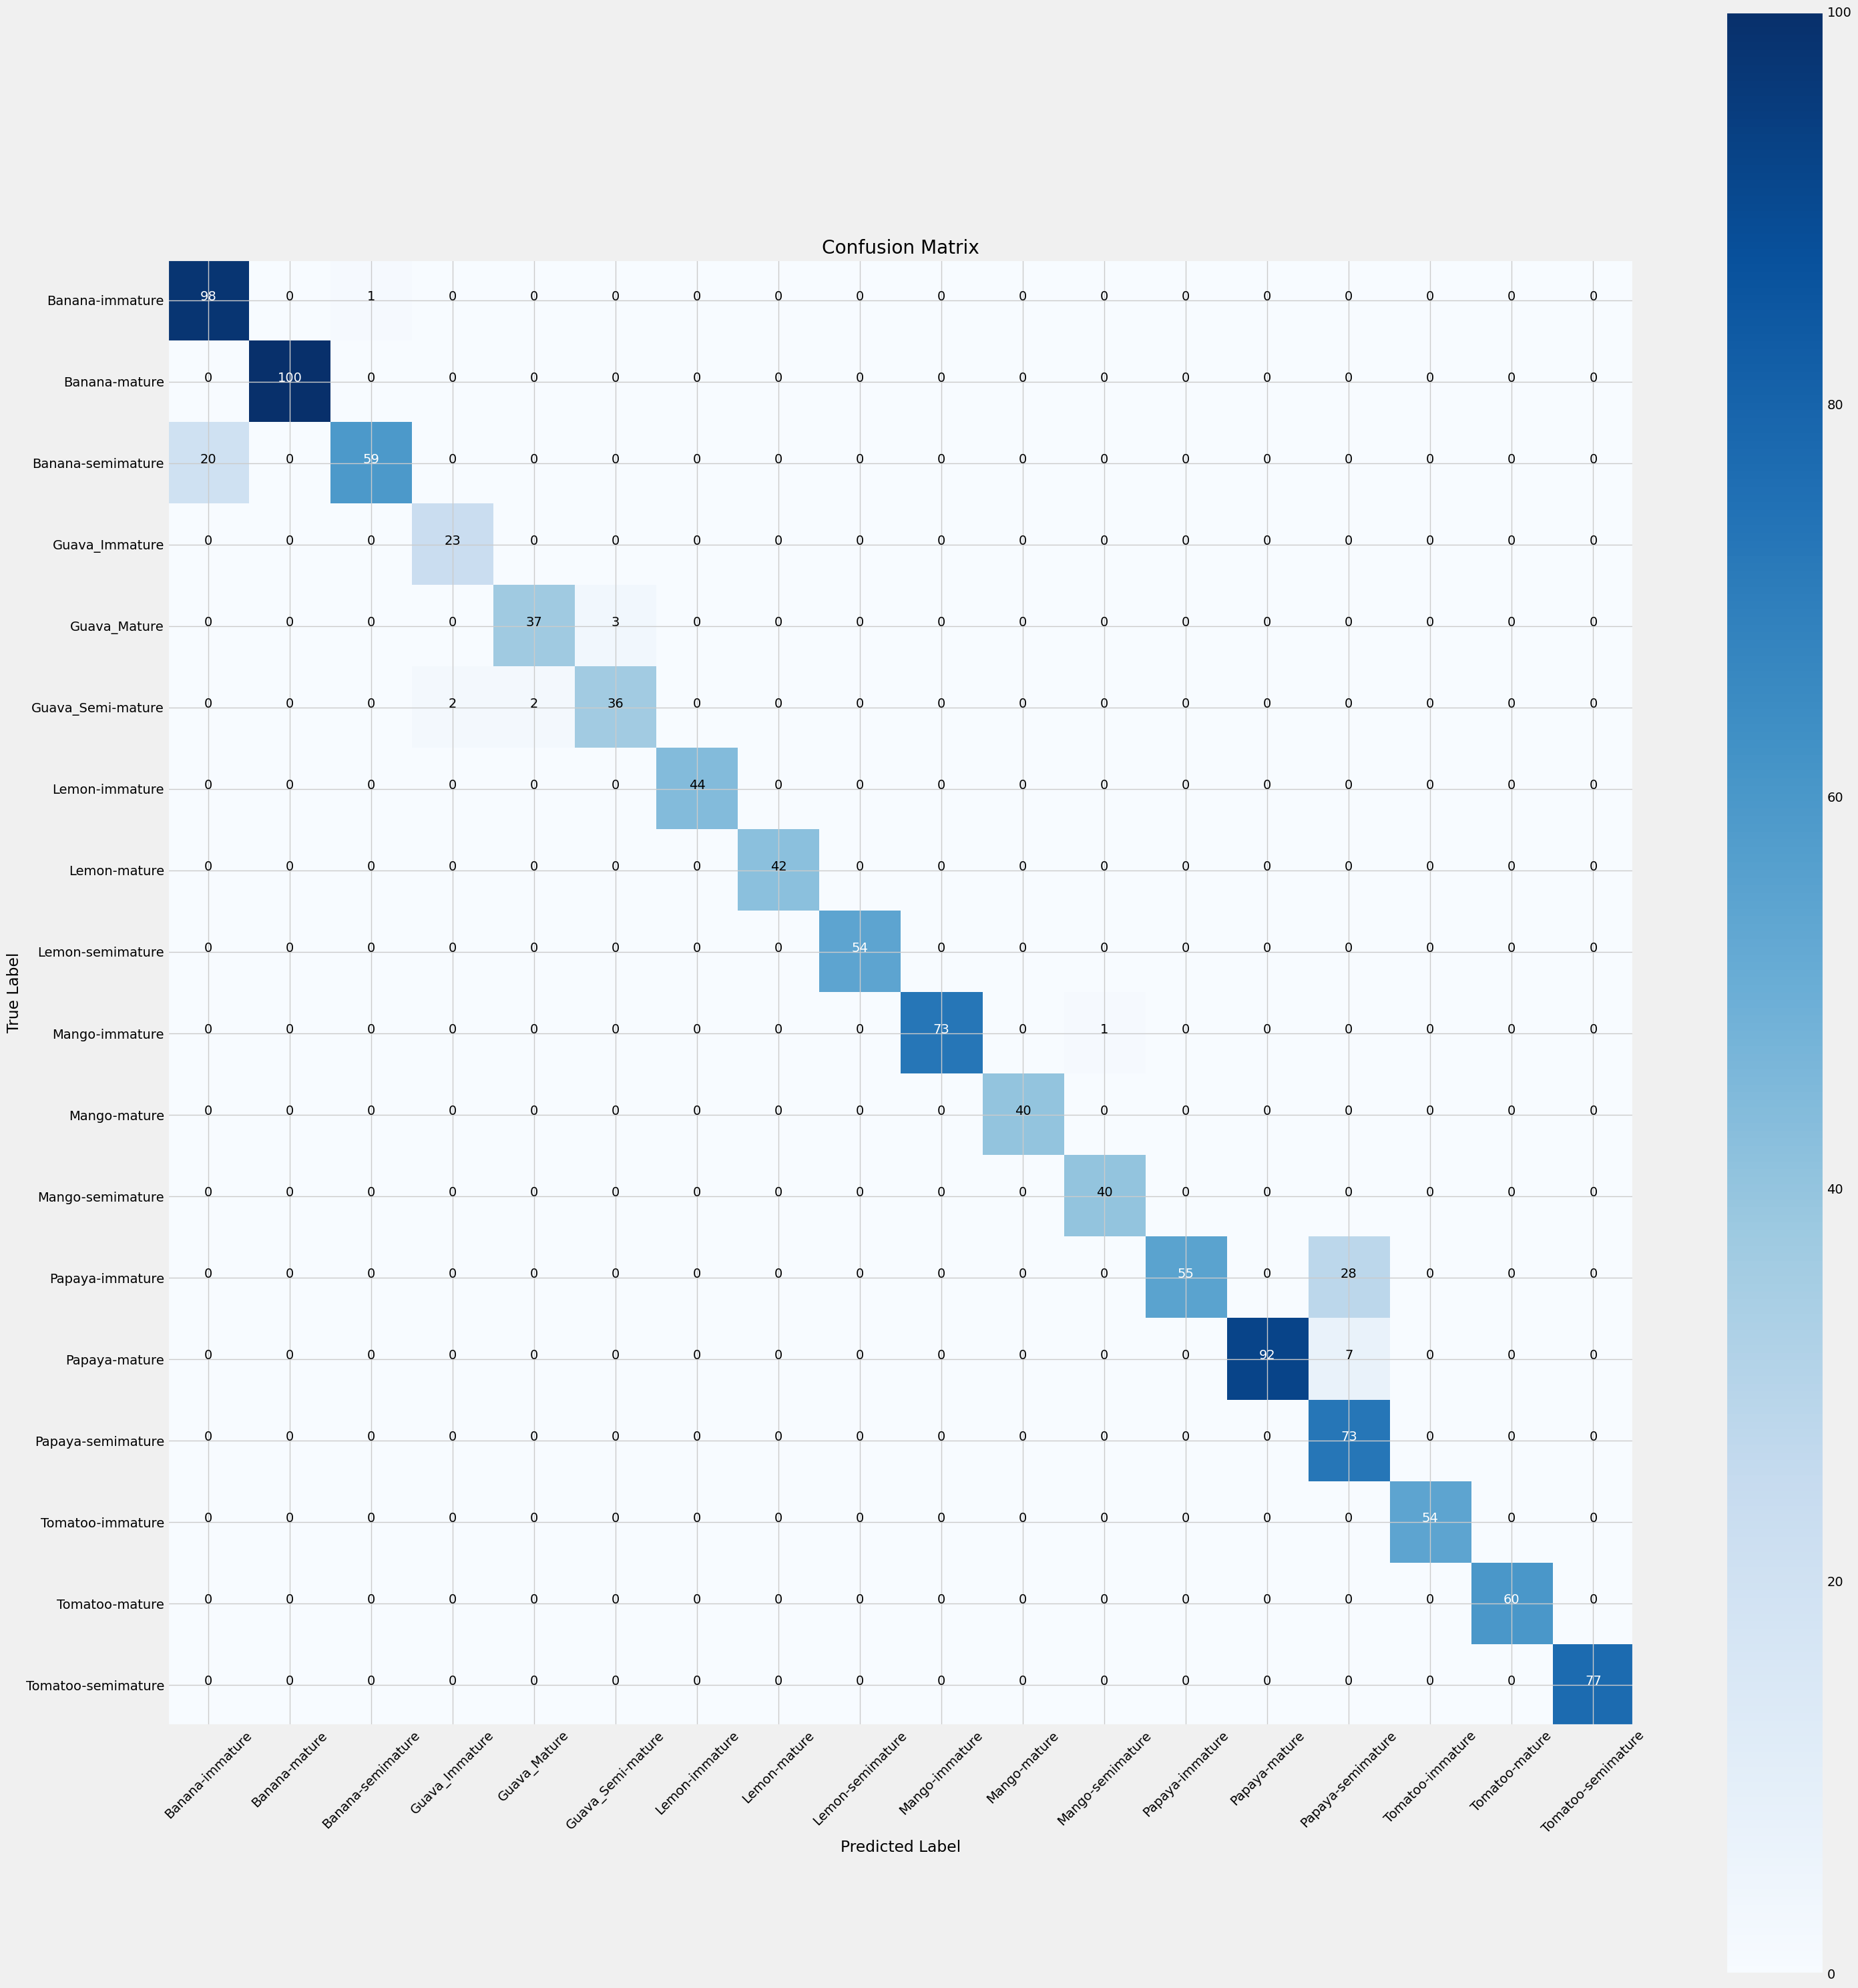

Key: EfficientNetB0, Value: <function preprocess_input at 0x7f1d5dcb6dd0>
Found 7626 validated image filenames belonging to 18 classes.
Found 1171 validated image filenames belonging to 18 classes.
Found 1121 validated image filenames belonging to 18 classes.
16705208/16705208 [==============================] - 0s 0us/step
Epoch 1/100
239/239 [==============================] - 44s 143ms/step - loss: 0.4791 - accuracy: 0.8733 - val_loss: 1.1600 - val_accuracy: 0.8335 - lr: 0.0100
Epoch 2/100
239/239 [==============================] - 33s 137ms/step - loss: 0.1936 - accuracy: 0.9437 - val_loss: 0.8980 - val_accuracy: 0.8651 - lr: 0.0100
Epoch 3/100
239/239 [==============================] - 33s 138ms/step - loss: 0.1559 - accuracy: 0.9521 - val_loss: 0.2304 - val_accuracy: 0.9266 - lr: 0.0100
Epoch 4/100
239/239 [==============================] - 34s 141ms/step - loss: 0.1250 - accuracy: 0.9607 - val_loss: 0.8356 - val_accuracy: 0.8728 - lr: 0.0100
Epoch 5/100
239/239 [==================

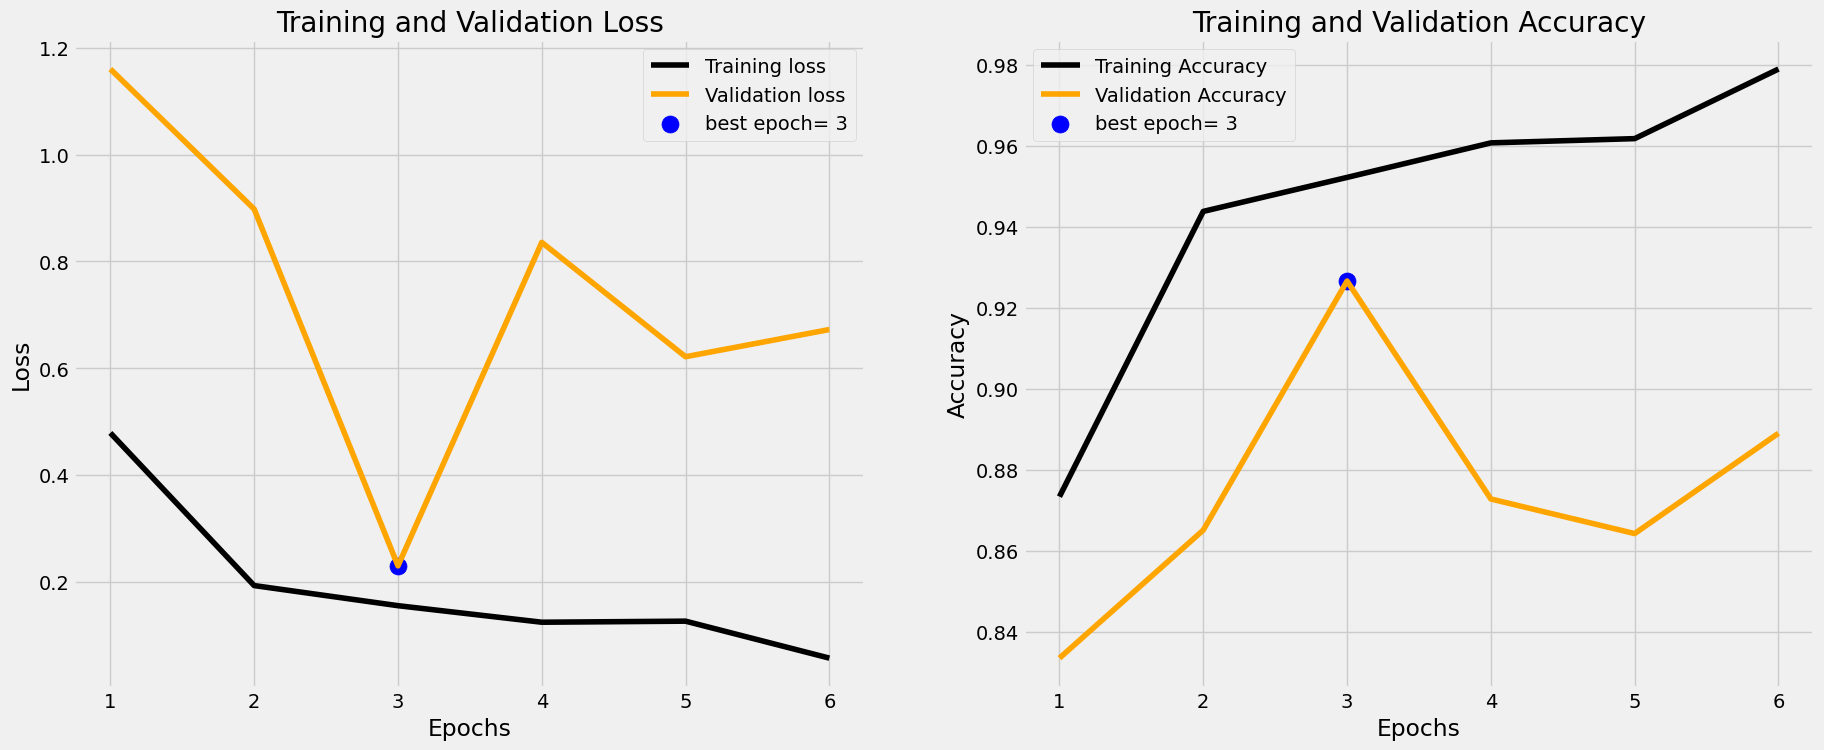

Evaluation results for EfficientNetB0 saved to /content/drive/MyDrive/Thesis/result.txt
36/36 [==============================] - 5s 110ms/step
F1 Score and Classification Report for EfficientNetB0 saved to /content/drive/MyDrive/Thesis/result.txt


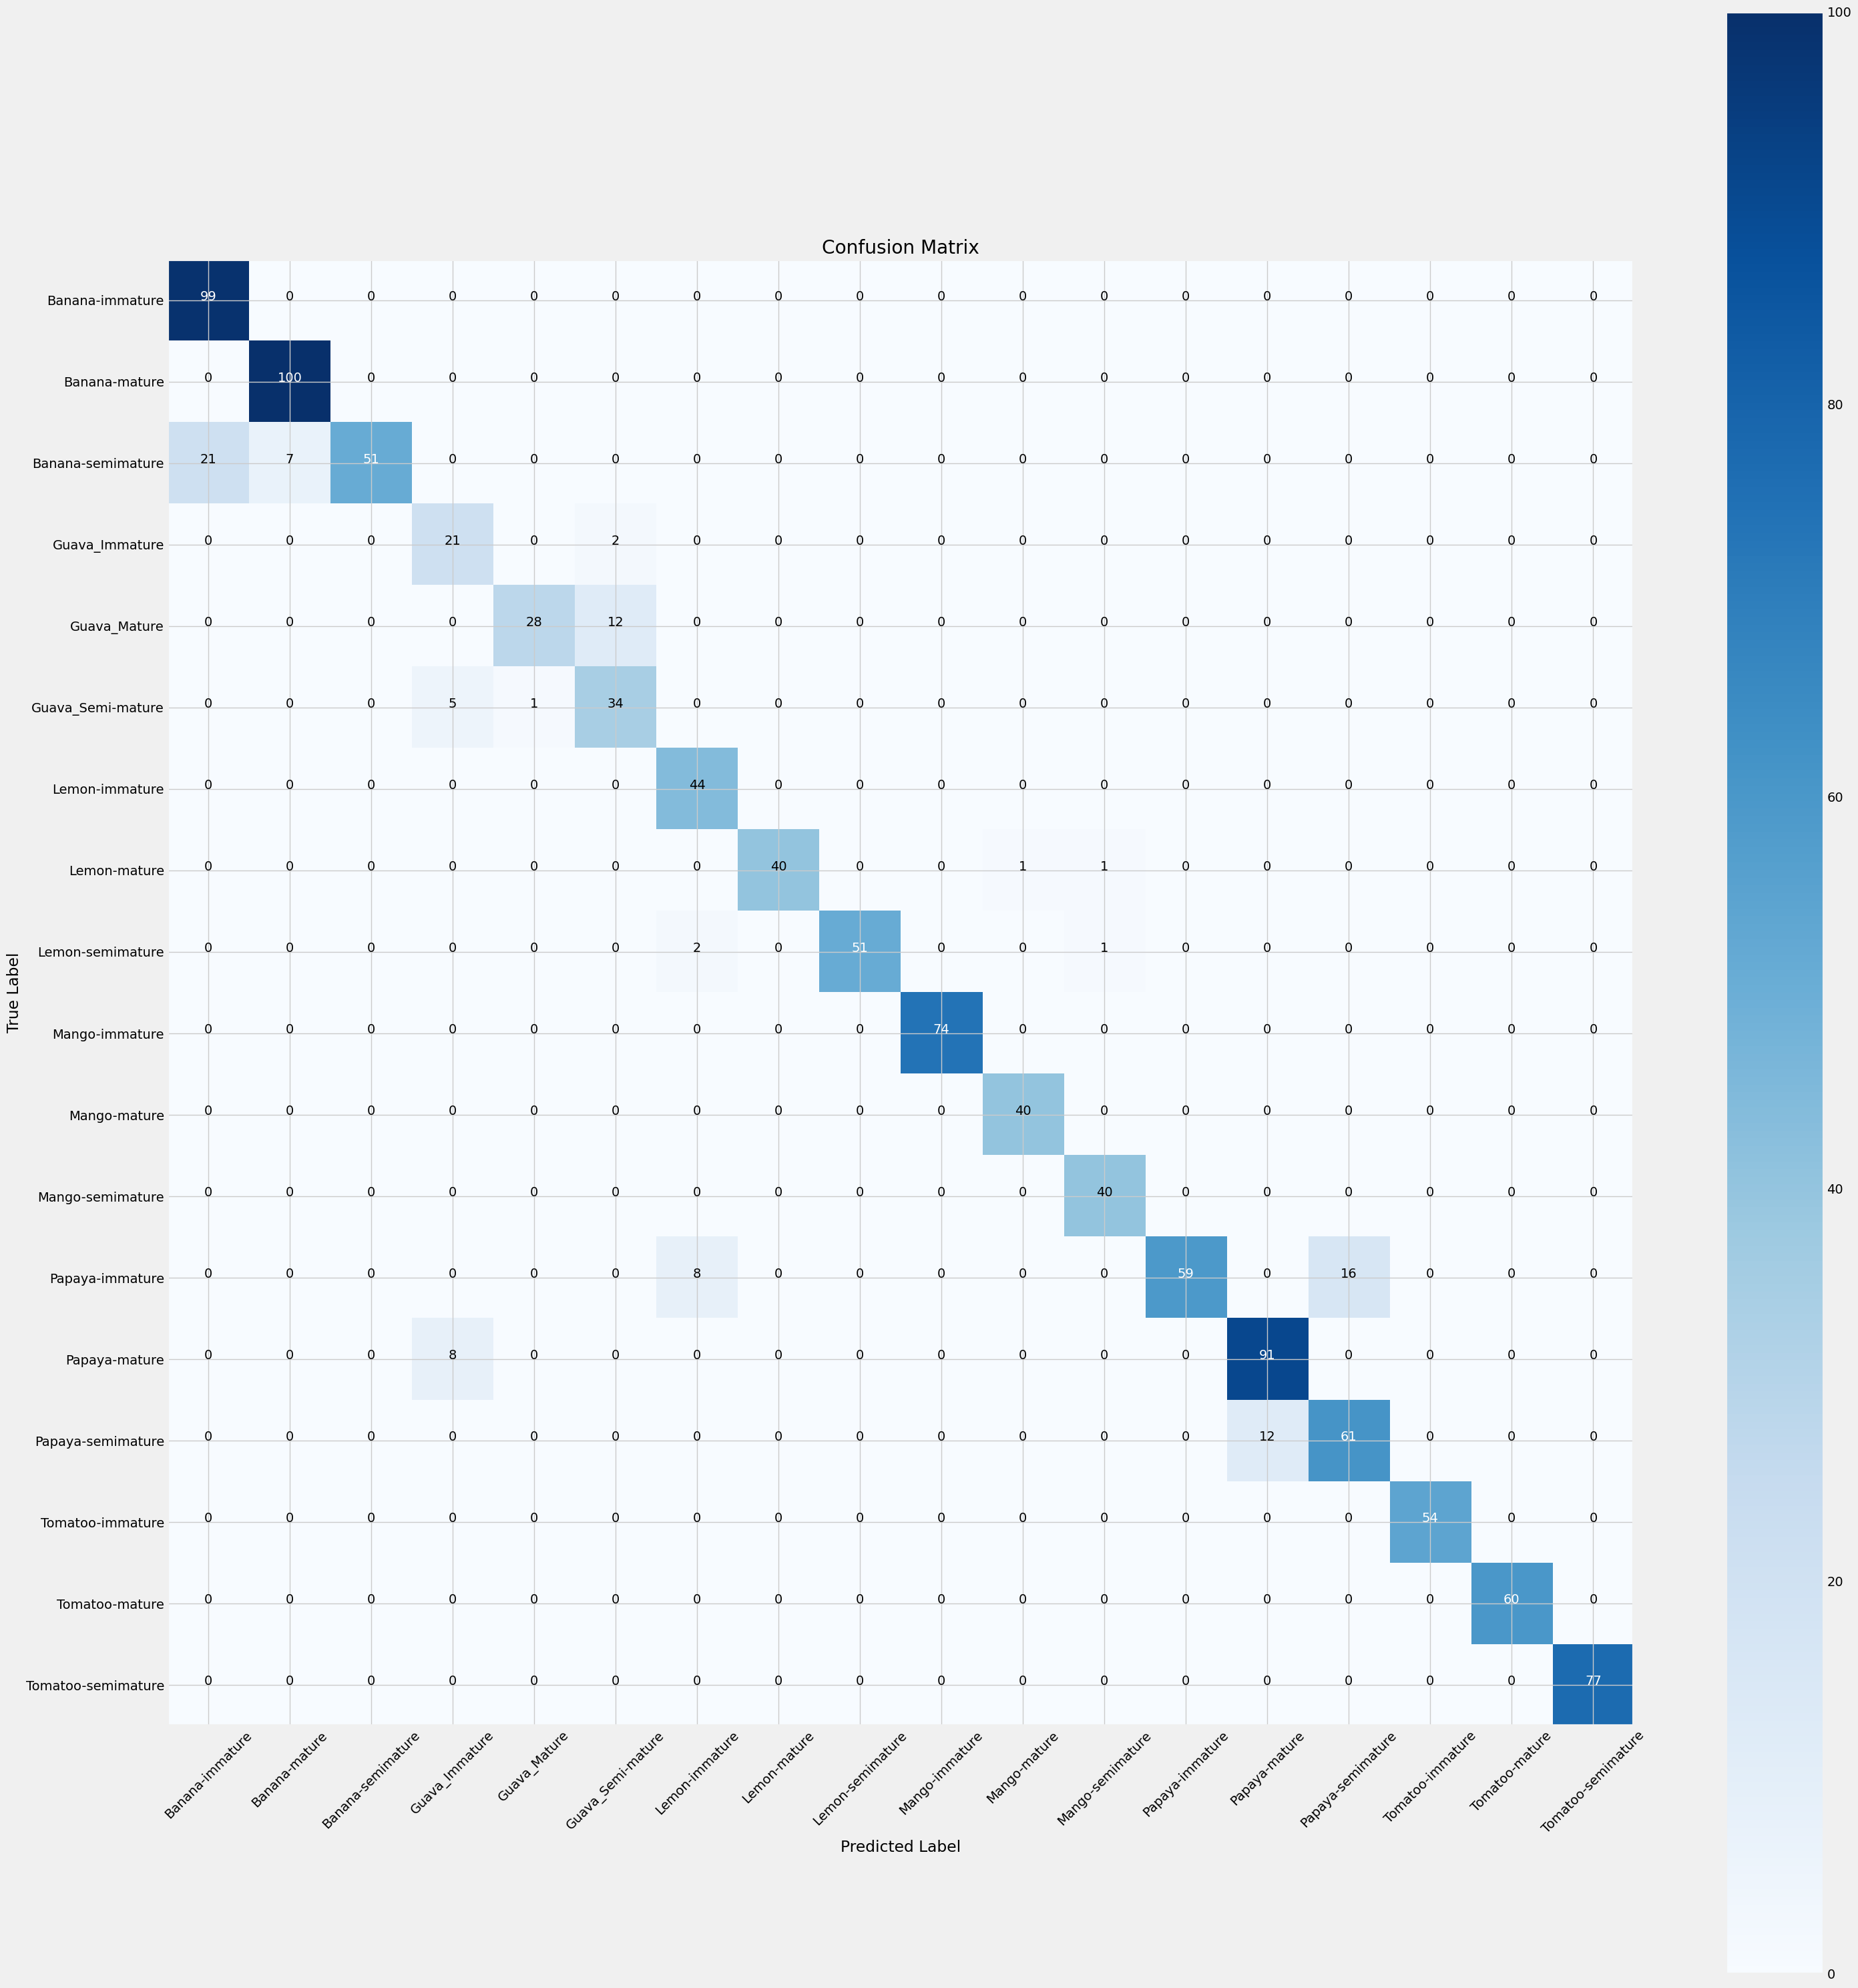

In [37]:
# Load the pretained model
for key, value in preprocess_functions.items():
  print(f"Key: {key}, Value: {value}")
  train_images,val_images,test_images=image_gen_and_preprocess(value)
  model_module = __import__('tensorflow.keras.applications', fromlist=[key])
    # Get the class dynamically using getattr
  model_class = getattr(model_module, key)
  pretrained_model =model_class(
      input_shape=(224, 224, 3),
      include_top=False, # we don`t need a pre-trained top layer (output layer)
      weights='imagenet',
      pooling='max'
  )
  # Freezing the layers of a pretrained neural network
  for i, layer in enumerate(pretrained_model.layers):
      pretrained_model.layers[i].trainable = False

  #Print Summary of the model.
  # pretrained_model.summary()

  #Add external Layers

  num_classes = len(set(train_images.classes))
  # Data Augmentation Step
  # augment = tf.keras.Sequential([
  #   layers.experimental.preprocessing.RandomFlip("horizontal"),
  #   layers.experimental.preprocessing.RandomRotation(0.15),
  #   layers.experimental.preprocessing.RandomZoom(0.12),
  #   layers.experimental.preprocessing.RandomContrast(0.12),
  # ], name='AugmentationLayer')

  inputs = layers.Input(shape = (224,224,3), name='inputLayer')
  x = inputs
  pretrain_out = pretrained_model(x, training = False)
  x = layers.Dense(1024)(pretrain_out)
  x = layers.Activation(activation="relu")(x)
  x = BatchNormalization()(x)
  x = layers.Dropout(0.45)(x)
  x = layers.Dense(512)(x)
  x = layers.Activation(activation="relu")(x)
  x = BatchNormalization()(x)
  x = layers.Dropout(0.3)(x)
  x = layers.Dense(num_classes)(x)
  outputs = layers.Activation(activation="softmax", dtype=tf.float32, name='activationLayer')(x) # mixed_precision need separated Dense and Activation layers
  model = Model(inputs=inputs, outputs=outputs)
  #compile the architechture.

  model.compile(
      optimizer=Adam(0.01),
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

  #print Model Summary.
  # print(model.summary())

  #plot the model.
  # plot_model(model = model, show_shapes = True)

  #start training.
  history = model.fit(
    train_images,
    steps_per_epoch=len(train_images),
    validation_data=val_images,
    validation_steps=len(val_images),
    epochs=100,
    callbacks=[
        EarlyStopping(monitor = "val_loss",
                               patience = 3,
                               restore_best_weights = True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, mode='min')
    ]
)
  model.save(f'/content/drive/MyDrive/Thesis/models/{key}.h5')

  #Now plot training loss by validation loss curve.
  # Define needed variables
  tr_acc = history.history['accuracy']
  tr_loss = history.history['loss']
  val_acc = history.history['val_accuracy']
  val_loss = history.history['val_loss']
  index_loss = np.argmin(val_loss)
  val_lowest = val_loss[index_loss]
  index_acc = np.argmax(val_acc)
  acc_highest = val_acc[index_acc]
  Epochs = [i+1 for i in range(len(tr_acc))]
  loss_label = f'best epoch= {str(index_loss + 1)}'
  acc_label = f'best epoch= {str(index_acc + 1)}'

  # Plot training history
  plt.figure(figsize= (20, 8))
  plt.style.use('fivethirtyeight')

  plt.subplot(1, 2, 1)
  plt.plot(Epochs, tr_loss, 'black', label= 'Training loss')
  plt.plot(Epochs, val_loss, 'orange', label= 'Validation loss')
  plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
  plt.title('Training and Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(Epochs, tr_acc, 'black', label= 'Training Accuracy')
  plt.plot(Epochs, val_acc, 'orange', label= 'Validation Accuracy')
  plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
  plt.title('Training and Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.tight_layout
  plt.savefig(f'{loss_graph}{key}.png')
  plt.show()


  #model Evaluation.
  results = model.evaluate(test_images, verbose=0)
  # Extract test loss and accuracy
  test_loss = results[0]
  test_accuracy = results[1]

  # Define the file path to save the results for each model
  file_path = f"{BASE_DIR}/results.txt"
  # Write the evaluation results to a text file for each model in each epoch
  with open(file_path, 'a') as file:  # Use 'a' to append results for each epoch
      file.write(f'------------writing details of {key}--------------\n')
      file.write(f'\tEvaluation Result:')
      file.write(f"Test Loss: {test_loss:.5f}, Test Accuracy: {test_accuracy * 100:.2f}%\n\n")
  print(f"Evaluation results for {key} saved to {file_path}")
  #writing Classification report to file
  y_true = test_images.classes
  y_pred = np.argmax(model.predict(test_images), axis=1)
  # Calculate F1 score
  f1 = f1_score(y_true, y_pred, average='macro')
  # Generate classification report
  report = classification_report(y_true, y_pred, target_names=test_images.class_indices.keys())
  # File path to save F1 score and classification report for each model
  file_path_classification = file_path
  # Write F1 score and classification report to a text file for each model in each epoch
  with open(file_path_classification, 'a') as file:  # Use 'a' to append results for each epoch
    file.write(f"F1 Score: {f1}\n")
    file.write("Classification Report:\n")
    file.write(report + "\n\n")
  print(f"F1 Score and Classification Report for {key} saved to {file_path_classification}")

  #Confusion matrix.
  preds = model.predict_generator(test_images)
  y_pred = np.argmax(preds, axis=1)
  g_dict = test_images.class_indices
  classes = list(g_dict.keys())

  # Confusion matrix
  cm = confusion_matrix(test_images.classes, y_pred)

  plt.figure(figsize= (30, 30))
  plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
  plt.title('Confusion Matrix')
  plt.colorbar()

  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation= 45)
  plt.yticks(tick_marks, classes)


  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

  plt.tight_layout()
  plt.ylabel('True Label')
  plt.xlabel('Predicted Label')
  plt.savefig(f'{confusion}{key}.png')
  plt.show()


